## Кейсы. Анализ образовательных метрик.

Задание: В компании Edtech продакт-менеджер попросил проанализировать поведение студентов на курсах, предметах и экзаменах онлайн-школы и ответить на ряд вопросов.

Работа ведется с 4 файлами:
1. assessments.csv — информация об оценках в тесте. Обычно каждый предмет в семестре включает ряд тестов с оценками, за которыми следует заключительный экзаменационный тест (экзамен).
- code_module — идентификационный код предмета.
- code_presentation — семестр (Идентификационный код).
- id_assessment — тест (Идентификационный номер ассессмента).
- assessment_type — тип теста. Существуют три типа оценивания: оценка преподавателя (TMA), компьютерная оценка (СМА), экзамен по курсу (Exam).
- date — информация об окончательной дате сдачи теста. Рассчитывается как количество дней с момента начала семестра. Дата начала семестра имеет номер 0 (ноль).
- weight — вес теста в % в оценке за курс. Обычно экзамены рассматриваются отдельно и имеют вес 100%. Сумма всех остальных оценок составляет 100%.
2. courses.csv - список предметов по семестрам
- code_module — предмет (идентификационный код).
- code_presentation — семестр (идентификационный код).
- module_presentation_length — продолжительность семестра в днях.
3. studentAssessment.csv — результаты тестов студентов (тех, кто отправил работу)
- id_assessment — тест (идентификационный номер).
- id_student — идентификационный номер студента.
- date_submitted — дата сдачи теста студентом, измеряемая как количество дней с начала семестра.
- is_banked — факт перезачета теста с прошлого семестра (иногда курсы перезачитывают студентам, вернувшимся из академического отпуска).
- score — оценка учащегося в этом тесте. Диапазон составляет от 0 до 100. Оценка ниже 40 неудачная/неуспешная сдача теста.
4. studentRegistration.csv — информациz о времени, когда студент зарегистрировался для прохождения курса в семестре
- code_module — предмет (идентификационный код).
- code_presentation — семестр (идентификационный код).
- id_student — идентификационный номер студента.
- date_registration — дата регистрации студента. Это количество дней, измеренное от начала семестра (например, отрицательное значение -30 означает, что студент зарегистрировался на прохождение курса за 30 дней до его начала)
- date_unregistration — дата отмены регистрации студента с предмета. У студентов, окончивших курс, это поле остается пустым.

Источник: Karpov Courses, курс "Аналитика данных" (https://karpov.courses/analytics), модуль "Продуктовая аналитика и A/B тесты"

In [17]:
pip install pingouin

Note: you may need to restart the kernel to use updated packages.


In [18]:
import numpy as np
import pandas as pd

import scipy.stats as st
import pingouin as pg

import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df_assess = pd.read_csv('assessments.csv')
df_courses = pd.read_csv('courses.csv')
df_results = pd.read_csv('studentAssessment.csv')
df_reg = pd.read_csv('studentRegistration.csv')

In [20]:
df_assess.head(10)

,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0
3,AAA,2013J,1755,TMA,166.0,20.0
4,AAA,2013J,1756,TMA,215.0,30.0
5,AAA,2013J,1757,Exam,NaN,100.0
6,AAA,2014J,1758,TMA,19.0,10.0
7,AAA,2014J,1759,TMA,54.0,20.0
8,AAA,2014J,1760,TMA,117.0,20.0
9,AAA,2014J,1761,TMA,166.0,20.0


In [21]:
df_courses.head(10)

,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240
5,BBB,2014B,234
6,CCC,2014J,269
7,CCC,2014B,241
8,DDD,2013J,261
9,DDD,2014J,262


In [22]:
df_results.head(10)

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0
5,1752,45462,20,0,70.0
6,1752,45642,18,0,72.0
7,1752,52130,19,0,72.0
8,1752,53025,9,0,71.0
9,1752,57506,18,0,68.0


In [23]:
df_reg.head(10)

,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN
5,AAA,2013J,38053,-110.0,NaN
6,AAA,2013J,45462,-67.0,NaN
7,AAA,2013J,45642,-29.0,NaN
8,AAA,2013J,52130,-33.0,NaN
9,AAA,2013J,53025,-179.0,NaN


## Кейс 1

**Сколько студентов успешно сдали только один курс?**

Для подсчёта числа успешно сданных экзаменов нужно использовать id_assessment - номер теста.

Нужны таблицы  StudentAssessment.csv (score) и Assessments.csv. Объединяю df_results и df_assess.

In [24]:
df = pd.merge(df_results, df_assess, how = 'inner', on = 'id_assessment')

In [25]:
df.head(10)

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight
0,1752,11391,18,0,78.0,AAA,2013J,TMA,19.0,10.0
1,1752,28400,22,0,70.0,AAA,2013J,TMA,19.0,10.0
2,1752,31604,17,0,72.0,AAA,2013J,TMA,19.0,10.0
3,1752,32885,26,0,69.0,AAA,2013J,TMA,19.0,10.0
4,1752,38053,19,0,79.0,AAA,2013J,TMA,19.0,10.0
5,1752,45462,20,0,70.0,AAA,2013J,TMA,19.0,10.0
6,1752,45642,18,0,72.0,AAA,2013J,TMA,19.0,10.0
7,1752,52130,19,0,72.0,AAA,2013J,TMA,19.0,10.0
8,1752,53025,9,0,71.0,AAA,2013J,TMA,19.0,10.0
9,1752,57506,18,0,68.0,AAA,2013J,TMA,19.0,10.0


В общей сложности есть 7 предметов. Интересно посмотреть, какие типы оценивания предусмотрены по каждому предмету. 

In [26]:
df.groupby(['code_module', 'assessment_type'], as_index=False)\
    .id_student.nunique()\
    .rename(columns={'id_student': 'num_students'})

# смотрю на типы оцениванивания по каждому предмету
# в num_students рассчитано количество студентов, принявших участие в тесте 

,code_module,assessment_type,num_students
0,AAA,TMA,677
1,BBB,CMA,3817
2,BBB,TMA,5941
3,CCC,CMA,3262
4,CCC,Exam,1915
5,CCC,TMA,2450
6,DDD,CMA,1046
7,DDD,Exam,3040
8,DDD,TMA,4636
9,EEE,TMA,2268


Посмотрю, сколько в принципе тестов проведено по каждому предмету.

In [27]:
df.groupby('code_module', as_index=False).id_assessment.nunique()

,code_module,id_assessment
0,AAA,10
1,BBB,38
2,CCC,18
3,DDD,35
4,EEE,12
5,FFF,48
6,GGG,27


Экзамены есть только по двум предметам - CCC и DDD. По условию они идут с весом 100%. То есть эти 2 предмета оцениваются по экзамену.

Вопрос в том, сколько студентов успешно сдали только один курс. Сначала рассмотрю только те два предмета, где оценивание происходит за счет экзамена. Успешной считается оценка не ниже 40. Рассматриваются два семестра. То есть смотрю за все семестры, какие студенты сдали только один курс.

In [118]:
# смотрю, сколько студентов успешно сдали в общей сложности
df.query("assessment_type == 'Exam' and score >= 40")\
.groupby('id_student')\
.aggregate({'id_assessment': 'nunique'}).size

4097

In [29]:
single_course = df.query("assessment_type == 'Exam' and score >= 40")\
.groupby('id_student')\
.aggregate({'id_assessment': 'nunique'}).query('id_assessment == 1')\
.rename(columns={'id_assessment': 'count'})\
.reset_index()

single_course

# список id студентов с только одним успешно сданным экзаменом 

,id_student,count
0,23698,1
1,24213,1
2,27116,1
3,28046,1
4,28787,1
...,...,...
3797,2694886,1
3798,2694933,1
3799,2695608,1
3800,2697181,1


In [120]:
single_course.shape
# таких студентов 3802

(3802, 2)

In [32]:
df_other = df.query("code_module != 'CCC' and code_module != 'DDD'").copy()
df_other 

# смотрю на другие предметы

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight
0,1752,11391,18,0,78.0,AAA,2013J,TMA,19.0,10.0
1,1752,28400,22,0,70.0,AAA,2013J,TMA,19.0,10.0
2,1752,31604,17,0,72.0,AAA,2013J,TMA,19.0,10.0
3,1752,32885,26,0,69.0,AAA,2013J,TMA,19.0,10.0
4,1752,38053,19,0,79.0,AAA,2013J,TMA,19.0,10.0
...,...,...,...,...,...,...,...,...,...,...
173907,37443,527538,227,0,60.0,GGG,2014J,CMA,229.0,0.0
173908,37443,534672,229,0,100.0,GGG,2014J,CMA,229.0,0.0
173909,37443,546286,215,0,80.0,GGG,2014J,CMA,229.0,0.0
173910,37443,546724,230,0,100.0,GGG,2014J,CMA,229.0,0.0


Создаю отдельный столбец, который будет фиксировать часть теста в суммарной оценке курса.

In [33]:
df_other['score_part'] = df_other['score'] * df_other['weight']/100
df_other.head(5)

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight,score_part
0,1752,11391,18,0,78.0,AAA,2013J,TMA,19.0,10.0,7.8
1,1752,28400,22,0,70.0,AAA,2013J,TMA,19.0,10.0,7.0
2,1752,31604,17,0,72.0,AAA,2013J,TMA,19.0,10.0,7.2
3,1752,32885,26,0,69.0,AAA,2013J,TMA,19.0,10.0,6.9
4,1752,38053,19,0,79.0,AAA,2013J,TMA,19.0,10.0,7.9


In [34]:
success = df_other.groupby(['id_student', 'code_module'], as_index=False)\
    .score_part.sum()\
    .query('score_part >= 40')

success

# фильтрую только по успешно закрывшим курс

,id_student,code_module,score_part
0,6516,AAA,63.50
1,11391,AAA,82.40
3,23798,BBB,89.24
6,24734,AAA,47.50
7,25107,BBB,60.51
...,...,...,...
17065,2698125,FFF,68.00
17066,2698257,AAA,69.40
17067,2698535,EEE,53.44
17068,2698577,BBB,55.80


In [35]:
other_subj = success.groupby('id_student')\
    .aggregate({'id_student': 'nunique'})\
    .rename(columns={'id_student': 'count'})\
    .reset_index()\
    .query('count == 1')

other_subj

# сколько раз каждый студент встречается в списке успешно закрывших курс
# фильтрую по тем, кто закрыл только один курс

,id_student,count
0,6516,1
1,11391,1
2,23798,1
3,24734,1
4,25107,1
...,...,...
11093,2698125,1
11094,2698257,1
11095,2698535,1
11096,2698577,1


In [36]:
std_all = pd.concat([single_course['id_student'], other_subj['id_student']])

# создала единый список студентов
# нужно убедиться, что они закрыли только один курс среди всех предметов

In [37]:
df_one = std_all.to_frame()\
    .groupby('id_student')\
    .aggregate({'id_student': 'nunique'})\
    .query('id_student == 1')

df_one

,id_student
id_student,
6516,1
11391,1
23698,1
23798,1
24213,1
...,...
2698251,1
2698257,1
2698535,1


In [38]:
df_one.size

14410

In [39]:
df.id_student.nunique()

23369

Получается, что студентов, которые закрыли только один курс, всего 14900. А всего студентов, сдававших тесты, 23369. Это 62% от всех тех, кто участвовал в тесте, и 50% от всех зарегистрировавшихся для прохождения курса.

In [40]:
df_one.size/df.id_student.nunique()

0.6166288673028371

In [41]:
df_one.size/df_reg.id_student.nunique()

0.5006079555323953

**Успеваемость по предметам и отдельным типам оценивания**

In [121]:
df.score.mean().round(2)

# средний балл по всем видам контроля

75.8

In [122]:
df.query("assessment_type == 'Exam'").score.mean().round(2)

# средний балл по экзаменам

65.57

In [42]:
df.groupby('code_module', as_index=False).score.mean().round(2)

# средний балл по предметам

,code_module,score
0,AAA,69.03
1,BBB,76.71
2,CCC,73.26
3,DDD,70.09
4,EEE,81.18
5,FFF,77.71
6,GGG,79.70


Средний балл за все семестры наиболее высокий по предмету EEE и самый низкий по предмету AAA.

In [43]:
df.groupby('assessment_type', as_index=False).score.mean().round(2)

# средний балл по каждому виду тестирования

,assessment_type,score
0,CMA,81.03
1,Exam,65.57
2,TMA,72.56


Наиболее высокие баллы в среднем студенты получают за задания с компьютерной оценкой. За экзамен в среднем средний балл самый низкий относительно других видов оценивания.

In [44]:
df.pivot_table(index=['code_presentation'], columns = ['code_module'], 
               values=['score'], aggfunc=['mean']).round(2)

mean                                          
                   score                                          
code_module          AAA    BBB    CCC    DDD    EEE    FFF    GGG
code_presentation                                                 
2013B                NaN  79.10    NaN  69.70    NaN  77.98    NaN
2013J              69.43  78.92    NaN  69.59  80.63  77.14  80.26
2014B                NaN  78.97  70.92  69.33  79.75  76.68  79.57
2014J              68.60  65.74  74.80  71.53  82.46  78.72  79.08

По семестрам можно отметить наиболее явную разницу в среднем балле по предмету BBB и явное его устойчивое сокращение. Предмет CCC преподается только в 2014 г. Во втором семестре средний балл возрос. По другим предметам средний балл сохраняет примерно один и тот же уровень.

In [45]:
df.pivot_table(index=['code_presentation'], columns = ['assessment_type'], 
               values=['score'], aggfunc=['mean']).round(2)

mean              
                   score              
assessment_type      CMA   Exam    TMA
code_presentation                     
2013B              79.74  56.35  72.42
2013J              84.11  65.01  72.35
2014B              80.16  69.61  72.58
2014J              79.78  66.03  72.82

При компьютерной оценке наиболее высокий средний балл наблюдался в семестре 2013J. В других семестрах он приближен к 80. Успеваемость по экзамену была сильно ниже в 2013B, но дальше возросла. Средний балл при оценке преподавателя остается почти не меняется.

**Связь между датой регистрации на курс и результатом**

Для этого присоединю таблицу df_reg с информацией о регистрациях. При этом нужно, чтобы в таблице оставались все зарегистрированные студенты, в том числе те, кто не проходил тесты.

In [46]:
dfr = pd.merge(df, df_reg, how = 'right')

In [47]:
with_score = dfr[~dfr.score.isna()].copy()

# смотрю только на тех, кто сдавал тесты

In [48]:
with_score.head()

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight,date_registration,date_unregistration
0,1752.0,11391,18.0,0.0,78.0,AAA,2013J,TMA,19.0,10.0,-159.0,NaN
1,1753.0,11391,53.0,0.0,85.0,AAA,2013J,TMA,54.0,20.0,-159.0,NaN
2,1754.0,11391,115.0,0.0,80.0,AAA,2013J,TMA,117.0,20.0,-159.0,NaN
3,1755.0,11391,164.0,0.0,85.0,AAA,2013J,TMA,166.0,20.0,-159.0,NaN
4,1756.0,11391,212.0,0.0,82.0,AAA,2013J,TMA,215.0,30.0,-159.0,NaN


<Axes: xlabel='date_registration', ylabel='score'>

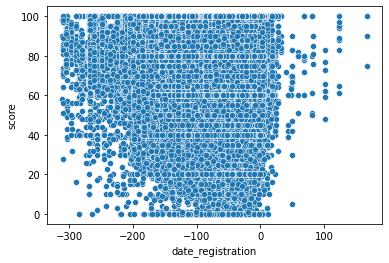

In [49]:
sns.scatterplot(data=with_score, x='date_registration', y='score')

Можно отметить, что большая часть студентов все-таки регистрируется на курс до начала семестра или непосредственно в день его начала. На графике видно, что студенты, которые зарегистрировались сильно заранее очень редко получают низкие баллы. При этом высокие баллы и у тех, кто зарегистривался уже ближе к началу. Меньше по количеству тех студентов, кто зарегистрировался после начала семестра, но их баллы сконрцентрированы в области значений, выше порогового (40). 

Относительно связи можно только сказать, что те студенты, кто регистрируется за очень долгий срок до начала семестра редко демонстрируют низкие результаты по тестам (все-таки склонны старательно учиться).

**Связь между датой регистрации на курс и временем на сдачу теста.**

<Axes: xlabel='date_registration', ylabel='date_submitted'>

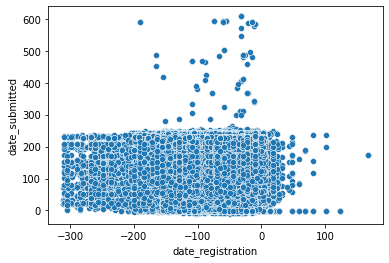

In [50]:
sns.scatterplot(data=with_score, x='date_registration', y='date_submitted')

Зависимости по диаграмме рассеивания не наблюдается. Нельзя сказать, что те студенты, кто заранее зарегистрировался на курс, сдают тесты в более ранние сроки, чем те, кто зарегистрировался позже или "впритык". 

**Зарегистрированные студенты, не прошедшие тесты.**

Смотрю именно на студентов, которые не отменили регистрацию, а просто не прошли тестирования.

In [51]:
no_assessment = dfr.query('id_assessment.isna() and date_unregistration.isna()')

In [52]:
no_assessment.id_student.count()

1351

In [53]:
no_assessment.id_student.nunique()

1308

In [54]:
no_assessment

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight,date_registration,date_unregistration
516,NaN,281589,NaN,NaN,NaN,AAA,2013J,NaN,NaN,NaN,-50.0,NaN
734,NaN,346843,NaN,NaN,NaN,AAA,2013J,NaN,NaN,NaN,-44.0,NaN
906,NaN,494424,NaN,NaN,NaN,AAA,2013J,NaN,NaN,NaN,-38.0,NaN
1549,NaN,2620584,NaN,NaN,NaN,AAA,2013J,NaN,NaN,NaN,-109.0,NaN
1770,NaN,111512,NaN,NaN,NaN,AAA,2014J,NaN,NaN,NaN,-16.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
180362,NaN,697456,NaN,NaN,NaN,GGG,2014J,NaN,NaN,NaN,-16.0,NaN
180370,NaN,698019,NaN,NaN,NaN,GGG,2014J,NaN,NaN,NaN,-1.0,NaN
180475,NaN,1890660,NaN,NaN,NaN,GGG,2014J,NaN,NaN,NaN,4.0,NaN
180596,NaN,2475886,NaN,NaN,NaN,GGG,2014J,NaN,NaN,NaN,-31.0,NaN


Всего уникальное количество таких студентов составляет 1308. Некоторые студентыв не прошли несколько тестирований.

In [125]:
dfr.query('date_unregistration.isna()').id_student.nunique()

# студенты, которые зарегистрировались и не отписались от курса

21190

In [129]:
round((1308/21190) * 100.0, 2)

# процент студентов, которые не пришли на тестирование

6.17

In [132]:
no_assessment.groupby('code_module', as_index=False)\
    .id_student.count()

,code_module,id_student
0,AAA,11
1,BBB,332
2,CCC,131
3,DDD,225
4,EEE,159
5,FFF,252
6,GGG,241


Лидеры по неявке студентов на тестирование (без отмены регистрации) - BBB, FFF, GGG. Близкий уровень у FFF. Сильно ниже значение у AAA.

In [56]:
students_id = (no_assessment.groupby('id_student')
    .agg(count = ('id_student','count'))
    .query('count > 1')
    .reset_index())['id_student']

# весь перечень студентов, которые пропустили больше одного тестирования

In [57]:
no_assessment.query('id_student in @students_id')[['id_student', 'code_module']]\
    .sort_values('id_student')

# можно посмотреть, тестирование по каким предметам пропустили

,id_student,code_module
48619,229499,CCC
87271,229499,DDD
48709,250092,CCC
103439,250092,EEE
48741,261042,CCC
...,...,...
159835,678474,FFF
55384,1908526,CCC
105148,1908526,EEE
91820,2710343,DDD


## Кейс 2

**Найдите и отсортируйте id экзаменов в рамках курса по возрастанию уровня завершаемости.**

Завершаемость = кол-во успешных экзаменов/кол-во всех попыток сдать экзамен * 100.

In [58]:
success_res = df.query("assessment_type == 'Exam' and score >= 40 and is_banked == 0")\
.groupby('id_assessment', as_index = False) \
.id_assessment.value_counts()

success_res

# расчет кол-ва успешных завершений экзамена

,id_assessment,count
0,24290,664
1,24299,1019
2,25340,504
3,25354,878
4,25361,485
5,25368,842


In [59]:
overall_ex = df.query("assessment_type == 'Exam' and is_banked == 0")\
.groupby('id_assessment', as_index = False) \
.id_assessment.value_counts()

overall_ex

# расчет кол-ва всех попыток сдать экзамен

,id_assessment,count
0,24290,747
1,24299,1168
2,25340,602
3,25354,968
4,25361,524
5,25368,950


In [60]:
tests_completed = pd.merge(success_res, overall_ex, how = 'inner', on = 'id_assessment')
tests_completed

,id_assessment,count_x,count_y
0,24290,664,747
1,24299,1019,1168
2,25340,504,602
3,25354,878,968
4,25361,485,524
5,25368,842,950


In [61]:
tests_completed['share'] = tests_completed['count_x']/tests_completed['count_y'] * 100

In [62]:
df_exams = tests_completed\
.rename(columns={'count_x': 'success_count', 'count_y': 'total_count'})\
.sort_values('share')

df_exams
# расположила id экзаменов в порядке возрастания уровня завершаемости

,id_assessment,success_count,total_count,share
2,25340,504,602,83.720930
1,24299,1019,1168,87.243151
5,25368,842,950,88.631579
0,24290,664,747,88.888889
3,25354,878,968,90.702479
4,25361,485,524,92.557252


Рассмотрю также, по каким предметам завершаемость экзаменов наиболее высокая. Чаще 

In [63]:
df_exams.columns.tolist()

['id_assessment', 'success_count', 'total_count', 'share']

In [64]:
exams_courses = pd.merge(df_exams, df, how = 'inner', on='id_assessment')
exams_courses.groupby(['id_assessment']).code_module.max().to_frame()

,code_module
id_assessment,
24290,CCC
24299,CCC
25340,DDD
25354,DDD
25361,DDD
25368,DDD


In [65]:
df.query("assessment_type == 'Exam'")\
    .groupby('code_module', as_index=False)\
    .id_assessment.nunique()

# видно, что в принципе всего было 6 экзаменов в общей сложности (за все семестры)

,code_module,id_assessment
0,CCC,2
1,DDD,4


Тем не менее, можно отметить, что выше завершаемость всех экзаменов, проведенных по предмету DDD.

## Кейс 3

**Выявите самые популярные предметы (ТОП-3) по количеству регистраций на них.**

Необходимо добавить информацию о регистрациях студентов, которая хранится в датафрейме df_reg.

In [66]:
dff = pd.merge(df, df_reg, how = 'inner')

In [67]:
dff.head(10)

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight,date_registration,date_unregistration
0,1752,11391,18,0,78.0,AAA,2013J,TMA,19.0,10.0,-159.0,NaN
1,1752,28400,22,0,70.0,AAA,2013J,TMA,19.0,10.0,-53.0,NaN
2,1752,31604,17,0,72.0,AAA,2013J,TMA,19.0,10.0,-52.0,NaN
3,1752,32885,26,0,69.0,AAA,2013J,TMA,19.0,10.0,-176.0,NaN
4,1752,38053,19,0,79.0,AAA,2013J,TMA,19.0,10.0,-110.0,NaN
5,1752,45462,20,0,70.0,AAA,2013J,TMA,19.0,10.0,-67.0,NaN
6,1752,45642,18,0,72.0,AAA,2013J,TMA,19.0,10.0,-29.0,NaN
7,1752,52130,19,0,72.0,AAA,2013J,TMA,19.0,10.0,-33.0,NaN
8,1752,53025,9,0,71.0,AAA,2013J,TMA,19.0,10.0,-179.0,NaN
9,1752,57506,18,0,68.0,AAA,2013J,TMA,19.0,10.0,-103.0,NaN


In [68]:
dff.groupby('code_module', as_index = False) \
    .id_student.nunique() \
    .sort_values('id_student', ascending = False)

,code_module,id_student
5,FFF,6058
1,BBB,5960
3,DDD,4699
2,CCC,3318
4,EEE,2268
6,GGG,2107
0,AAA,677


Лидеры по регистрации студентов - FFF, BBB, DDD.

## Кейс 4

**Выявите предметы с самым большим оттоком (ТОП-3)**

Отток в данном случае — это отмена регистрации на предмет. Считаю его в абсолютных значениях (т.е. количество людей, отменивших регистрацию). Нужна колонка date_unregistration. Значение в ней не должно быть Nan, что означает отмену регистрации.

In [69]:
dff.groupby('code_module', as_index = False) \
    .aggregate({'id_student': 'count'}) \
    .sort_values('id_student', ascending = False)

,code_module,id_student
5,FFF,54815
1,BBB,43032
3,DDD,30864
2,CCC,18940
6,GGG,15219
4,EEE,7893
0,AAA,3149


In [70]:
dff[~dff.date_unregistration.isna()]

# фильтрую таблицу по столбцу date_unregistration, где значения не пустые

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight,date_registration,date_unregistration
14,1752,65002,17,0,66.0,AAA,2013J,TMA,19.0,10.0,-180.0,96.0
21,1752,94961,17,0,74.0,AAA,2013J,TMA,19.0,10.0,-170.0,72.0
28,1752,106247,32,0,67.0,AAA,2013J,TMA,19.0,10.0,5.0,175.0
40,1752,129955,18,0,85.0,AAA,2013J,TMA,19.0,10.0,-197.0,135.0
43,1752,135400,19,0,72.0,AAA,2013J,TMA,19.0,10.0,-32.0,144.0
...,...,...,...,...,...,...,...,...,...,...,...,...
172057,37439,682481,128,0,100.0,GGG,2014J,CMA,229.0,0.0,-5.0,128.0
172185,37439,2214722,137,0,100.0,GGG,2014J,CMA,229.0,0.0,-23.0,206.0
172269,37440,680988,156,0,80.0,GGG,2014J,CMA,229.0,0.0,-73.0,156.0
172403,37440,2214722,157,0,80.0,GGG,2014J,CMA,229.0,0.0,-23.0,206.0


Понятно, что если студент отписывается от предмета, он отписывается от всех тестов. В таблице для каждого id_assessment есть запись о студенте, который отменил регистрацию, а также о дате отмены регистрации (которая для предмета будет едина). Это важно для понимания следующего шага.

In [71]:
dff[~dff.date_unregistration.isna()] \
.groupby('code_module', as_index = False) \
.aggregate({'id_student': 'nunique'}) \
.sort_values('id_student', ascending = False)

,code_module,id_student
5,FFF,1099
3,DDD,1068
2,CCC,1017
1,BBB,855
4,EEE,234
6,GGG,108
0,AAA,88


Если смотреть по уникальному количеству студентов, которые отменили регистрацию на предмет, то лидерами являются FFF, DDD, CCC.

In [72]:
dff[~dff.date_unregistration.isna()] \
.groupby('code_module', as_index = False) \
.aggregate({'id_student': 'count'}) \
.sort_values('id_student', ascending = False)

,code_module,id_student
3,DDD,3523
5,FFF,3397
1,BBB,2693
2,CCC,2531
4,EEE,421
6,GGG,270
0,AAA,220


Если смотреть по количеству отмен регистрации для каждого теста и вычислять общий отток по предмету (то есть насколько меньше стало писать каждый тест человек), то тогда рассчитывает не уникальное количество студентов. Лидерами являются предметы DDD, FFF, BBB.

## Кейс 5

**В период с начала 2013 по конец 2014 выявите семестр с самой низкой завершаемостью курсов.**

In [73]:
dff.code_presentation.unique() 
# втаблице есть информация о 4 семестрах

array(['2013J', '2014J', '2013B', '2014B'], dtype=object)

In [74]:
successes_num = dff.query("assessment_type == 'Exam' and score >= 40")\
.groupby('code_presentation', as_index = False) \
.aggregate({'id_assessment': 'count'})

successes_num

# кол-во успешных сдач экзаменов по семестрам

,code_presentation,id_assessment
0,2013B,504
1,2013J,878
2,2014B,1149
3,2014J,1861


In [75]:
overall_num = dff.query("assessment_type == 'Exam'")\
.groupby('code_presentation', as_index = False)\
.aggregate({'id_assessment': 'count'})

overall_num

# общее кол-во сдач экзаменов по семестрам

,code_presentation,id_assessment
0,2013B,602
1,2013J,968
2,2014B,1271
3,2014J,2118


In [76]:
compl_tests = pd.merge(successes_num, overall_num, 
         on = 'code_presentation', 
         how = 'inner')

compl_tests

,code_presentation,id_assessment_x,id_assessment_y
0,2013B,504,602
1,2013J,878,968
2,2014B,1149,1271
3,2014J,1861,2118


In [77]:
compl_tests['score'] = compl_tests['id_assessment_x']/compl_tests['id_assessment_y']

In [78]:
compl_tests

,code_presentation,id_assessment_x,id_assessment_y,score
0,2013B,504,602,0.837209
1,2013J,878,968,0.907025
2,2014B,1149,1271,0.904013
3,2014J,1861,2118,0.878659


Семестр с самой низкой завершаемостью курсов в семестре 2013B.

## Кейс 6

**В период с начала 2013 по конец 2014 выявите семестр с самыми долгими средними сроками сдачи курсов.**

В date хранится информация об окончательной дате сдачи теста (относительно начала семестра). В date_submitted о дате сдачи теста студентом (тоже относительно начала семестра).

Для начала проведу предварительный анализ.

In [79]:
dff.groupby('code_presentation', as_index = False) \
.aggregate({'date_submitted': 'mean'}) \
.sort_values('date_submitted', ascending = False)

,code_presentation,date_submitted
1,2013J,119.857195
3,2014J,116.979607
2,2014B,114.034605
0,2013B,111.328554


В среднем студенты дольше всего затратили времени на выполнение тестов в семестре 2013J.

In [80]:
dff.groupby('code_presentation', as_index = False) \
.aggregate({'date': 'mean'}) \
.sort_values('date', ascending = False)

,code_presentation,date
1,2013J,138.952181
3,2014J,130.220093
2,2014B,126.452541
0,2013B,123.764398


В среднем больше всего давалось времени на выполнение тестов тоже в семестре 2013J. При этом по количеству проводимых тестов этот семестр не лидировал, их больше проводилось в семестрах 2014 г. Нельзя сказать, что было больше предметов (расчеты ниже). Если смотреть на продолжительность семестрa, то наиболее длительными семестрами являются 2014J и 2013J. Вероятно, давалось больше времени из-за сложности или объема тестов в семестре 2013J.

In [81]:
dff.groupby('code_presentation', as_index=False)\
    .id_assessment.nunique()

,code_presentation,id_assessment
0,2013B,37
1,2013J,48
2,2014B,52
3,2014J,51


In [82]:
dff.groupby(['code_presentation', 'code_module'], as_index=False)\
    .id_assessment.nunique()

,code_presentation,code_module,id_assessment
0,2013B,BBB,11
1,2013B,DDD,14
2,2013B,FFF,12
3,2013J,AAA,5
4,2013J,BBB,11
5,2013J,DDD,7
6,2013J,EEE,4
7,2013J,FFF,12
8,2013J,GGG,9
9,2014B,BBB,11


In [83]:
df_courses.groupby('code_presentation', as_index=False)\
    .module_presentation_length.max().round(2)\
    .sort_values('module_presentation_length', ascending=False)

# смотрю на продолжительность семестра

,code_presentation,module_presentation_length
3,2014J,269
1,2013J,268
2,2014B,241
0,2013B,240


Отдельно смотрю только на средние сроки сдачи экзаменов.

In [84]:
dff.query("assessment_type == 'Exam'")\
    .groupby('code_presentation', as_index = False) \
    .aggregate({'date_submitted': 'mean'}) \
    .sort_values('date_submitted', ascending = False)

,code_presentation,date_submitted
3,2014J,243.674221
1,2013J,239.505165
2,2014B,232.988985
0,2013B,230.179402


Средний срок сдачи экзамена у студентов наибольший в 2014J.

Далее смотрю на топ-5 самых времязатратных тестов в каждый семестр.

In [85]:
table1 = dff.groupby(['code_presentation', 'id_assessment'], as_index=False)\
    .agg(mean_days = ('date_submitted', 'mean')).round(2)\
    .sort_values(by=['code_presentation', 'mean_days'], ascending=[True, False])

table1

,code_presentation,id_assessment,mean_days
17,2013B,25340,230.18
24,2013B,25347,209.11
35,2013B,34870,204.61
36,2013B,34871,202.76
16,2013B,25339,198.79
...,...,...,...
167,2014J,34899,21.66
151,2014J,24295,20.59
137,2014J,1758,18.66
156,2014J,25362,17.47


In [86]:
table1['rank'] = table1.groupby('code_presentation', group_keys=False)\
    .mean_days.rank(method='dense', ascending=False)

table1

,code_presentation,id_assessment,mean_days,rank
17,2013B,25340,230.18,1.0
24,2013B,25347,209.11,2.0
35,2013B,34870,204.61,3.0
36,2013B,34871,202.76,4.0
16,2013B,25339,198.79,5.0
...,...,...,...,...
167,2014J,34899,21.66,47.0
151,2014J,24295,20.59,48.0
137,2014J,1758,18.66,49.0
156,2014J,25362,17.47,50.0


In [87]:
top5_by_semester = table1[table1['rank'] <= 5]

top5_by_semester

,code_presentation,id_assessment,mean_days,rank
17,2013B,25340,230.18,1.0
24,2013B,25347,209.11,2.0
35,2013B,34870,204.61,3.0
36,2013B,34871,202.76,4.0
16,2013B,25339,198.79,5.0
59,2013J,25354,239.51,1.0
84,2013J,37423,221.56,2.0
74,2013J,34883,214.56,3.0
41,2013J,1756,214.54,4.0
75,2013J,34884,212.12,5.0


## Кейс 7

Провожу сегментацию. Строю адаптированные RFM-кластеры студентов, чтобы качественно оценить аудиторию. В адаптированной кластеризации использую следующие метрики:

R — среднее время сдачи одного экзамена,

F — завершаемость курсов,

M — среднее количество баллов, получаемое за экзамен.

Первоначально определяю:
  1. Чему равна минимальная граница по recency?

  2. Чему равна максимальная граница по recency?

  3. Чему равна минимальная граница по monetary?

  4. Чему равна максимальная граница по monetary?

Сегментация проводится по результатам экзаменов.

In [88]:
dff.describe()

,id_assessment,id_student,date_submitted,is_banked,score,date,weight,date_registration,date_unregistration
count,173912.000000,1.739120e+05,173912.000000,173912.000000,173739.000000,171047.000000,173912.000000,173905.000000,13055.000000
mean,26553.803556,7.051507e+05,116.032942,0.010977,75.799573,130.605623,12.743899,-65.940778,138.127461
std,8829.784254,5.523952e+05,71.484148,0.104194,18.798107,78.025175,17.877301,47.049350,61.123371
min,1752.000000,6.516000e+03,-11.000000,0.000000,0.000000,12.000000,0.000000,-311.000000,-196.000000
25%,15022.000000,5.044290e+05,51.000000,0.000000,65.000000,54.000000,0.000000,-94.000000,95.000000
50%,25359.000000,5.852080e+05,116.000000,0.000000,80.000000,129.000000,9.000000,-53.000000,145.000000
75%,34883.000000,6.344980e+05,173.000000,0.000000,90.000000,214.000000,18.000000,-29.000000,184.000000
max,37443.000000,2.698588e+06,608.000000,1.000000,100.000000,261.000000,100.000000,167.000000,444.000000


In [89]:
rfm_exams = dff.query("assessment_type == 'Exam'")\
    .groupby('id_student', as_index=False)\
    .agg(
        recency=('date_submitted', 'mean'),
        all_scores=('score', 'count')
    )


# расчёт среднего времени сдачи одного экзамена (для recency)
# кол-во сдач экзамена (для frequency)

In [90]:
rfm_exams

,id_student,recency,all_scores
0,23698,243.0,1
1,24213,236.0,1
2,27116,243.0,1
3,28046,237.0,1
4,28787,243.0,1
...,...,...,...
4628,2694886,236.0,1
4629,2694933,230.0,1
4630,2695608,237.0,1
4631,2697181,230.0,1


In [91]:
exams_success = dff.query("assessment_type == 'Exam' and score >= 40")

In [143]:
exams_success.id_student.nunique()

4097

In [92]:
success_scores_by_students = exams_success\
    .groupby('id_student', as_index=False)\
    .agg(success_scores=('score', 'count'))

# кол-во успешных сдач экзамена (для frequency)

In [93]:
success_scores_by_students

,id_student,success_scores
0,23698,1
1,24213,1
2,27116,1
3,28046,1
4,28787,1
...,...,...
4092,2694886,1
4093,2694933,1
4094,2695608,1
4095,2697181,1


In [94]:
# Объединение таблиц, полученных выше
rfm_exams = rfm_exams.merge(success_scores_by_students, how='left', on='id_student').fillna(0)

In [95]:
rfm_exams

,id_student,recency,all_scores,success_scores
0,23698,243.0,1,1.0
1,24213,236.0,1,1.0
2,27116,243.0,1,1.0
3,28046,237.0,1,1.0
4,28787,243.0,1,1.0
...,...,...,...,...
4628,2694886,236.0,1,1.0
4629,2694933,230.0,1,1.0
4630,2695608,237.0,1,1.0
4631,2697181,230.0,1,1.0


In [96]:
#Frequency — завершаемость курсов

rfm_exams['frequency'] = (100 * rfm_exams.success_scores / rfm_exams.all_scores).round(2)
rfm_exams

,id_student,recency,all_scores,success_scores,frequency
0,23698,243.0,1,1.0,100.0
1,24213,236.0,1,1.0,100.0
2,27116,243.0,1,1.0,100.0
3,28046,237.0,1,1.0,100.0
4,28787,243.0,1,1.0,100.0
...,...,...,...,...,...
4628,2694886,236.0,1,1.0,100.0
4629,2694933,230.0,1,1.0,100.0
4630,2695608,237.0,1,1.0,100.0
4631,2697181,230.0,1,1.0,100.0


In [97]:
#M — среднее количество баллов, получаемое за экзамен
all_scores_by_student = dff.query("assessment_type == 'Exam'")\
    .groupby('id_student', as_index=False)\
    .agg(monetary=('score', 'mean'))

all_scores_by_student

,id_student,monetary
0,23698,80.0
1,24213,58.0
2,27116,96.0
3,28046,40.0
4,28787,44.0
...,...,...
4628,2694886,69.0
4629,2694933,73.0
4630,2695608,73.0
4631,2697181,80.0


In [98]:
# Объединение таблиц
rfm_exams = rfm_exams.merge(all_scores_by_student, how='left', on='id_student').fillna(0)

In [99]:
rfm_exams

,id_student,recency,all_scores,success_scores,frequency,monetary
0,23698,243.0,1,1.0,100.0,80.0
1,24213,236.0,1,1.0,100.0,58.0
2,27116,243.0,1,1.0,100.0,96.0
3,28046,237.0,1,1.0,100.0,40.0
4,28787,243.0,1,1.0,100.0,44.0
...,...,...,...,...,...,...
4628,2694886,236.0,1,1.0,100.0,69.0
4629,2694933,230.0,1,1.0,100.0,73.0
4630,2695608,237.0,1,1.0,100.0,73.0
4631,2697181,230.0,1,1.0,100.0,80.0


In [100]:
rfm_exams = rfm_exams[['id_student', 'recency', 'frequency', 'monetary']]
rfm_exams.describe()

,id_student,recency,frequency,monetary
count,4.633000e+03,4633.000000,4633.000000,4633.000000
mean,7.256904e+05,238.462227,88.128642,65.117958
std,5.753498e+05,5.653378,32.114175,20.470561
min,2.369800e+04,229.000000,0.000000,0.000000
25%,5.011580e+05,234.000000,100.000000,50.000000
50%,5.884820e+05,241.000000,100.000000,66.000000
75%,6.463510e+05,243.000000,100.000000,82.000000
max,2.698251e+06,285.000000,100.000000,100.000000


In [101]:
rfm_exams['recency'].min() 
# минимальная граница по recency

229.0

In [102]:
rfm_exams['recency'].max() 
# максимальная граница по recency

285.0

In [103]:
rfm_exams['monetary'].min()
# минимальная граница по monetary

0.0

In [104]:
rfm_exams['monetary'].max()

# максимальная граница по monetary

100.0

## Кейс 11

Расставляю баллы по следующей логике:

1) по recency можно получить 2, если значение recency меньше либо равно медиане по recency. В остальных случаях — 1.

2) по frequency можно получить 1, если значение frequency меньше 50. Можно получить 2, если значение по frequency меньше 100. Можно получить 3 в остальных случаях.

3) по monetary можно получить 1, если значение monetary меньше 40. Можно получить 2, если значение по monetary меньше либо равно 80. Можно получить 3 в остальных случаях.

In [105]:
rfm_exams['recency'].median()

241.0

In [106]:
def r_score(x):
    if x <= rfm_exams['recency'].median():
        return 2
    else:
        return 1

In [107]:
def f_score(x):
    if x < 50:
        return 1
    elif x < 100 and x >= 50:
        return 2
    else:
        return 3

In [108]:
def m_score(x):
    if x < 40:
        return 1
    elif x <= 80 and x >= 40:
        return 2
    else:
        return 3

In [109]:
rfm_exams['R_score'] = rfm_exams['recency'].apply(lambda x: r_score(x))
rfm_exams['F_score'] = rfm_exams['frequency'].apply(lambda x: f_score(x))
rfm_exams['M_score'] = rfm_exams['monetary'].apply(lambda x: m_score(x))

/var/folders/c3/w7qjybw54j10g8b6s1j6wst80000gn/T/ipykernel_38527/611445522.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm_exams['R_score'] = rfm_exams['recency'].apply(lambda x: r_score(x))


In [110]:
rfm_exams

,id_student,recency,frequency,monetary,R_score,F_score,M_score
0,23698,243.0,100.0,80.0,1,3,2
1,24213,236.0,100.0,58.0,2,3,2
2,27116,243.0,100.0,96.0,1,3,3
3,28046,237.0,100.0,40.0,2,3,2
4,28787,243.0,100.0,44.0,1,3,2
...,...,...,...,...,...,...,...
4628,2694886,236.0,100.0,69.0,2,3,2
4629,2694933,230.0,100.0,73.0,2,3,2
4630,2695608,237.0,100.0,73.0,2,3,2
4631,2697181,230.0,100.0,80.0,2,3,2


In [111]:
rfm_exams['RFM_Score'] = rfm_exams['R_score'].map(str) + rfm_exams['F_score'].map(str) + rfm_exams['M_score'].map(str)

In [112]:
rfm_exams

,id_student,recency,frequency,monetary,R_score,F_score,M_score,RFM_Score
0,23698,243.0,100.0,80.0,1,3,2,132
1,24213,236.0,100.0,58.0,2,3,2,232
2,27116,243.0,100.0,96.0,1,3,3,133
3,28046,237.0,100.0,40.0,2,3,2,232
4,28787,243.0,100.0,44.0,1,3,2,132
...,...,...,...,...,...,...,...,...
4628,2694886,236.0,100.0,69.0,2,3,2,232
4629,2694933,230.0,100.0,73.0,2,3,2,232
4630,2695608,237.0,100.0,73.0,2,3,2,232
4631,2697181,230.0,100.0,80.0,2,3,2,232


In [113]:
stud_by_cluster = rfm_exams.groupby('RFM_Score', as_index = False)\
    .agg({'id_student': 'nunique'})

In [114]:
stud_by_cluster

# количество студентов в каждом rfm кластере

,RFM_Score,id_student
0,111,267
1,121,1
2,122,3
3,132,1325
4,133,611
5,211,269
6,221,6
7,222,18
8,232,1555
9,233,578


In [115]:
dff.query("assessment_type == 'Exam' and date_submitted > date")\
    .id_student.count()

# кол-во студентов, которые пропустили дедлайн 

7

Интерпретация сегментов (в которые попало наибольшее количество учащихся):
1. RFM-score = 111

"Отстающие студенты": длительный срок сдачи работ, низкий уровень завершаемости курсов и низкие баллы по экзамену. 

2. RFM-score = 132

"Застревающие студенты": высокий уровень завершаемости курсов, неплохие баллы за экзамен, но более медленные

3. RFM-score = 133

"Медленные, но с особенно выдающимися результатами": вероятно, более загруженные. Вероятно, могут нарушать дедлайн. Портрет студентов схож с кластером 132, но студенты текущего сегмента демонстрируют более высокие результаты.

4. RFM-score = 211:

"Студенты-спринтеры". Выполняют быстро, но не качественно. 

5. RFM-score = 232:

"Твердые хорошисты". Студенты, которые большую часть экзаменов закрывают успешно и в короткие сроки, демонстрируют хороший результат.

6. RFM-score = 233

"Лучшие студенты". Успевают сделать быстро и демонстрируют высокие результаты.

<Axes: xlabel='RFM_Score', ylabel='count'>

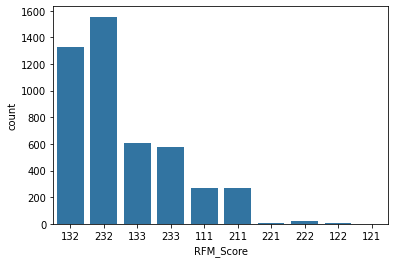

In [116]:
sns.countplot(data = rfm_exams, x = 'RFM_Score')

In [144]:
1555/4097

# доля студентов сегмента 232 от общего количества сдающих экзамен

0.3795460092750793

In [145]:
1325/4097 

# доля студентов сегмента 132 от общего количества сдающих экзамен

0.3234073712472541

In [137]:
exam_dff = dff.query("assessment_type == 'Exam'").copy()

In [138]:
df_segment = pd.merge(exam_dff, rfm_exams, how='inner', on='id_student')

df_segment

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight,date_registration,date_unregistration,recency,frequency,monetary,R_score,F_score,M_score,RFM_Score
0,24290,558914,230,0,32.0,CCC,2014B,Exam,NaN,100.0,-74.0,NaN,230.0,0.0,34.0,2,1,1,211
1,24290,559706,234,0,78.0,CCC,2014B,Exam,NaN,100.0,-22.0,NaN,232.0,100.0,75.5,2,3,2,232
2,24290,559770,230,0,54.0,CCC,2014B,Exam,NaN,100.0,-22.0,NaN,230.0,100.0,54.0,2,3,2,232
3,24290,560114,230,0,64.0,CCC,2014B,Exam,NaN,100.0,-281.0,NaN,230.0,100.0,57.5,2,3,2,232
4,24290,560311,234,0,100.0,CCC,2014B,Exam,NaN,100.0,-28.0,NaN,232.0,100.0,86.5,2,3,3,233
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4954,25368,652680,243,0,91.0,DDD,2014J,Exam,NaN,100.0,-144.0,NaN,243.0,100.0,91.0,1,3,3,133
4955,25368,652732,249,0,47.0,DDD,2014J,Exam,NaN,100.0,-17.0,NaN,249.0,100.0,47.0,1,3,2,132
4956,25368,652965,242,0,87.0,DDD,2014J,Exam,NaN,100.0,-142.0,NaN,242.0,100.0,87.0,1,3,3,133
4957,25368,653051,242,0,27.0,DDD,2014J,Exam,NaN,100.0,-60.0,NaN,242.0,0.0,27.0,1,1,1,111


In [152]:
df_segment.groupby('RFM_Score', as_index=False)\
    .agg(median_score=('monetary', 'median'), 
         median_time=('recency', 'median'),
        median_success=('frequency', 'median'))

,RFM_Score,median_score,median_time,median_success
0,111,31.00,243.00,0.0
1,121,33.50,243.50,50.0
2,122,49.50,243.00,50.0
3,132,62.00,243.00,100.0
4,133,91.00,243.50,100.0
5,211,33.00,232.25,0.0
6,221,36.75,239.25,50.0
7,222,48.25,237.75,50.0
8,232,62.00,234.00,100.0
9,233,90.00,234.00,100.0


**Вывод по итогам RFM-кластеризации:** наибольшее количество студентов относится к кластеру 232. На втором месте по количеству студентов - сегмент 132. Таким образом, основная масса наших студентов - это те, кто закрывают экзамены со средними баллами, тем не менее успешно. Больше тех, кто завершает экзамен в более короткий срок, но большое количество и таких студентов, кому нужно больше времени на работу.